# Calibration: Schools

## Overview

Calibration is often the trickiest part of any risk analysis. The goal of a CLIMADA calibration is to choose an impact function (or functions) that can best reproduce observations from previous events plus any other risk data you have.

We recommend always calibrating your risk model, even if you've had success with a particular impact function in the past. This is because

- Impact functions from the literature were almost always designed for different hazard models, different exposure data, and different contexts. They aren't transferrable to new contexts right out of the box.
- Impact functions change a lot with the resolution of your data.
- There are often biases or in your particular hazard or exposure datasets.
- Each study has its own context: there are always unmodelled, local conditions that can affect impacts.

In general calibrations need to be done for every combination of hazard type and exposure type that you are modelling. However, you will often find that one calibration can inform others – e.g. if you don't have many observations on damages to businesses in your study area, but you have information on damages to housing, and you know that your first-guess impact functions needed to be adjusted down, it's reasonable to assume you'll want to make a similar adjustment to the first-guess impact function for businesses.

Calibrations are usually done by one of

- **Manual calibration:** taking a first-guess impact function and manually adjusting it, repeating the risk calculation, comparing it to your observations, and repeating this until you are satisfied with the outputs.
- **Automated calibration:** specifying a family of impact functions, and using software to find the 'best' impact function within that family, according to some cost function that you specify.
- **Some combination of the both!** Where you get a sense of the kind of impact functions that work in your study, and then refine.

The approach that works best for you will depend on the number of observations that you're fitting to, other constraints in what you consider to be an acceptable solution, the complexity of code that you're prepared to write, and the time you have available. With approach (2) there is no limit to the complexity of algorithms you can design to search parameter spaces and optimise within constraints. See for example the new [Calibration module](https://climada-python.readthedocs.io/en/v6.1.0/user-guide/climada_util_calibrate.html) within CLIMADA, designed (for now) for calibrations where you are modelling a set of events where each has an observed loss.


**Tips:**

- Before you start calibrating get an understanding of your data. Ask yourself some of the following:
    - What is the rough shape of the impact function you are creating? Do impacts increase slowly or quickly with the hazard? What would the maximum impact be? What shape does the curve take?
    - In your model, what range of hazard value intensities affect the assets that you're modelling? Your function should be defined across this range. (Check in the data – you are creating an impact function for the hazard that you have, not the hazard that you imagine.)
    - Are your losses driven by small impacts at lots of locations, or large impacts at a few locations? This will tell you which part of the curve to focus on.
    - Are historical losses more from large, rare events, or from more frequent events that occur e.g. every few years? This will tell you which events to focus on getting right.
    - What functions and functional forms have been used elsewhere in the literature and are they appropriate?
- The impact of zero hazard should usually be zero. If this is not the case (e.g. with temperature or drought data), we recommend transforming or masking the hazard (e.g. setting all values to zero below some threshold at which impacts start) so that 0 hazard has zero impact. This greatly speeds up the calculations and avoids unexpected bugs.
- Make sure that you are calculating something represented by your summary statistics, or something that is close. For example:
    - Make sure the area you are modelling matches the area that your observations apply to (Ica is both a city and a Departement in Peru!).
    - Make sure the hazard data represents the processes you care about (a river flood model will struggle to reproduce flash flood losses, a drought model will struggle to reproduce heatwave losses).
- In some calibrations you will want to go beyond just the impact function, and will decide to adjust other parts of the risk calculation. For example:
    - You may want to apply bias corrections to the hazard data (e.g. corrections to flood data based on gauge histories, corrections to rainfall intensities based on an observational dataset)
    - If you are consistently getting high or low losses, check if your exposure values could be biased low (e.g. sometimes building replacement costs are more than the building value (but less than the value of the building + land, take note of what your value date represents!)). There may be a reason to scale the values of Exposures
    - You may have knowledge about something the model represents poorly: e.g. an area that is well-defended against floods and which you may choose to mask from the hazard, or a new neighborhood or piece of infrastructure not in the Exposure data


### Automated calibration to multiple observations

In this notebook we explore simple parameter search routines designed to help choose appropriate impact functions for schools in Porto Alegre.

In this calculation, we will

- Read in and visualize the individual components of risk
- Write reusable methods to run the risk calculation and to compare the results to the observations
- Define a cost function to quantify how well the model is able to reproduce observations
- Write an optimization routine that tries to minimise this cost function over a family of impact functions. We do this for
  - Affected schools (calibrating a step function)
  - Economic losses (adjusting an existing loss curve)


In [23]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILE = "Porto_Alegre_BRAZIL_Entity_Floods_Schools.xlsx"
entity_filepath = Path(ENTITY_DIR) / ENTITY_FILE

CALIBRATED_ENTITY_DIR = "../data/entity_files_calibrated/"
CALIBRATED_ENTITY_FILE = "Porto_Alegre_BRAZIL_Entity_Floods_Schools_calibrated.xlsx"
calibrated_entity_filepath = Path(CALIBRATED_ENTITY_DIR) / CALIBRATED_ENTITY_FILE

HAZARD_DIR = "../data/hazard/"
HAZARD_FILE = "Brazil_Porto_Alegre_2024_duration.tif"
haz_filepath = Path(HAZARD_DIR) / HAZARD_FILE

OBSERVATIONS_DIR = "../data/observations/"
OBSERVATIONS_FILE = "observations_2024.csv"
observations_filepath = Path(OBSERVATIONS_DIR) / OBSERVATIONS_FILE


## Load the components of risk

During the calibration we will be running risk calculations and plotting outputs repeatedly. To do this, we wrap the functionality of the central loop in reusable methods.

### Load the Entity file

In [24]:
import copy
from climada.entity import Entity

impf_column = "impf_FL"   # Impact function column in the assets table
impf_id_loss = 301        # ID of the impact function for economic loss that we're calibrating
impf_id_affected = 302    # ID of the impact function for affected schools that we're calibrating

# Read the Entity file
def read_entity(path, value_column):
    entity = Entity.from_excel(path)

    # In one part of the calibration, we calibrate against _number of buildings_ that are affected or destroyed
    # In the Entity file the 'value' column contains building value information in USD, and the e.g. 'housing_count' 
    # column contains the number of buildings. So we rename the columns so that the 'value' column contains the 
    # information we want.
    if value_column == 'value':
        return entity
    new_gdf = entity.exposures.gdf.copy()
    new_gdf["value"] = new_gdf[value_column]
    entity.exposures.set_gdf(new_gdf)
    return entity

# Read the Entity file for USD value
entity_usd = read_entity(entity_filepath, value_column='value')
entity_usd.exposures.ref_year = 2025
entity_usd.exposures.value_unit = "USD"
entity_usd.exposures.description = "Economic value"

# Read the Entity file for housing count
entity_count = read_entity(entity_filepath, value_column='count')
entity_count.exposures.ref_year = 2025
entity_count.exposures.value_unit = "number of schools"
entity_count.exposures.description = "Number of schools"

#### Plot exposures

The Schools Exposures aren't a complete dataset of Porto Alegre schools: these are the ones that are considered to be affected, roughly overlapping with the hazard footprint.

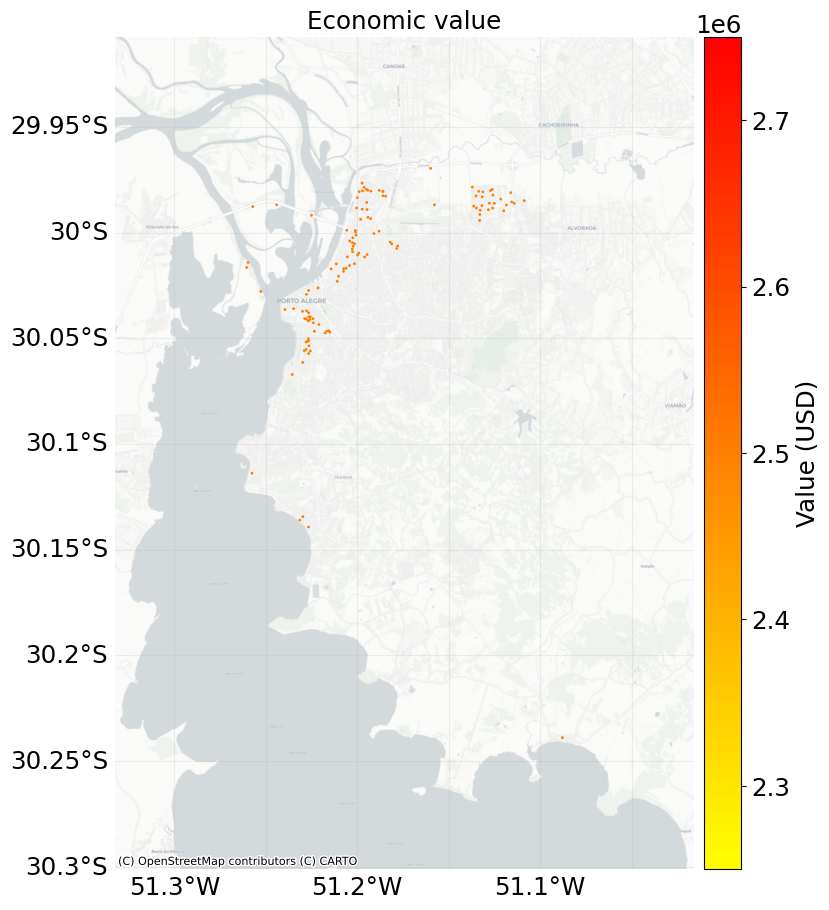

In [25]:
# Plot the exposures
_ = entity_usd.exposures.plot_basemap(
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=8000,             # Add a buffer around the points to show a larger map region (measured in meters)
        s=1,                     # The size of point markers on the plot
        zoom=13,                 # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)          # Dimensions of the output figure
    )


#### Plot impact functions

There are a few ways to approach a calibration like this, depending on the statistics you want to produce and the purposes of the calibration.

Our approach is going to look at two flood damage curves, each describing a different risk metric:
- A depth-damage curve that estimates the % loss at a point of exposure.
- An 'affected' step-function. This gives the threshold at which a school is considered to be affected by the flood

We have first-guess versions of these impact functions in the Entity file:

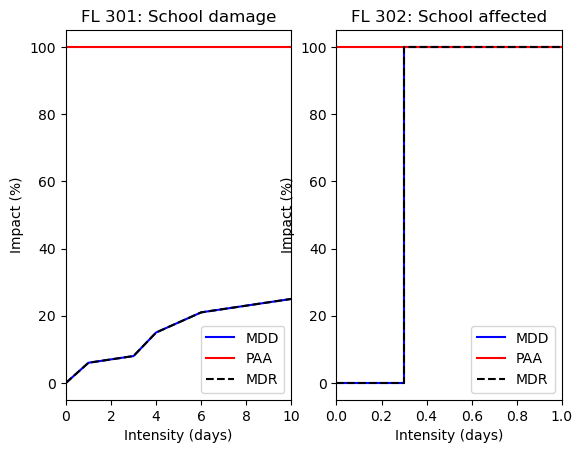

In [26]:
# Plot the impact functions
_ = entity_usd.impact_funcs.plot()

### Load Hazard data

The Hazard data is a single event footprint in a .tif file containing information on flood duration in days. We provide additional metadata to CLIMADA as we read this in.

In [27]:
import numpy as np
from climada.hazard import Hazard

# Read in the hazard data
haz = Hazard.from_raster(
    files_intensity = haz_filepath,
    attrs={
        'unit': 'days',
        'event_name': ['2024 Flood'],     # We can optionally name the events
        'frequency': np.array([1])        # For a historic event reconstruction we set the frequency to 1: there is no probabilistic analysis to do here
    },
    haz_type='FL',
    window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
    geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
)

2026-06-11 18:06:20,402 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_2024_duration.tif
2026-06-11 18:06:25,742 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_2024_duration.tif


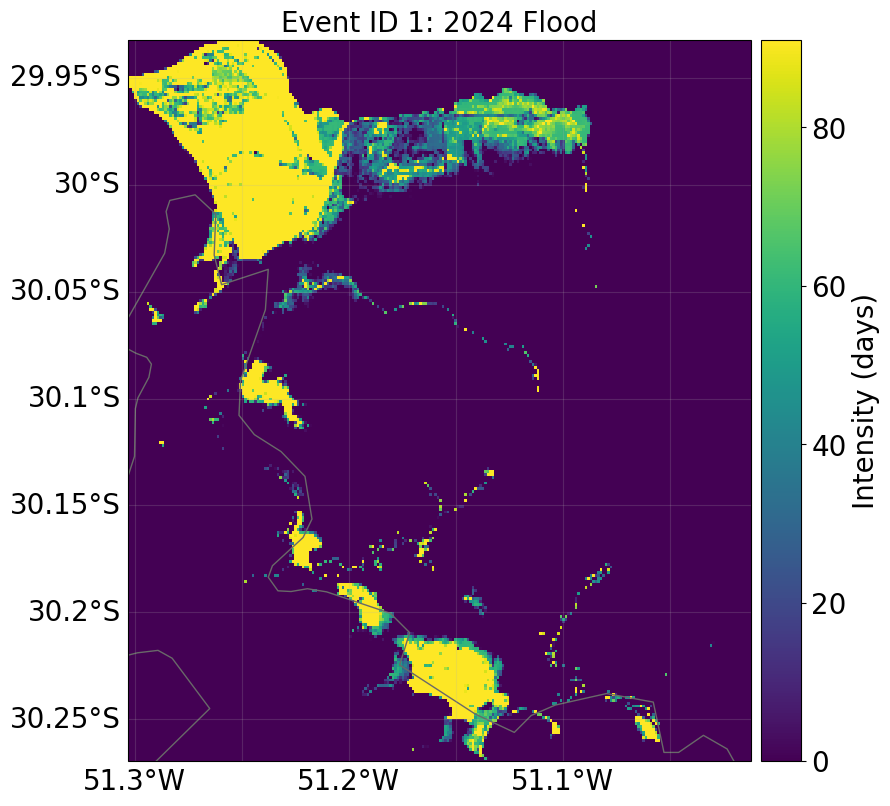

In [28]:
# Plot the maximum intensity across all events
_ = haz.plot_intensity(event=1)

In [29]:
# Assign hazard centroids to the exposures
entity_usd.exposures.assign_centroids(hazard=haz, overwrite=True)
entity_count.exposures.assign_centroids(hazard=haz, overwrite=True)

assert entity_usd.exposures.gdf['centr_FL'].isna().sum() == 0, "Some exposures do not have an assigned hazard centroid."
assert entity_count.exposures.gdf['centr_FL'].isna().sum() == 0, "Some exposures do not have an assigned hazard centroid."

2026-06-11 18:16:56,976 - climada.entity.exposures.base - INFO - Matching 122 exposures with 1354664 centroids.
2026-06-11 18:16:59,452 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0005387914992240894 degree
2026-06-11 18:17:00,033 - climada.entity.exposures.base - INFO - Matching 122 exposures with 1354664 centroids.
2026-06-11 18:17:00,943 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.0005387914992240894 degree


### Load observations

We read in the observations that we have for impacts to schools.

We also compare them to the Exposures data we have: the number of reported schools impacted is larger than the number of schools in our dataset, and this will be important in the calibration, and the reported loss is also very high.

In [30]:
import pandas as pd

BRL_to_USD = 0.18  # 2024 Exchange rate

obs = pd.read_csv(observations_filepath)

obs_schools = obs[obs["Asset type"] == "Schools"]

obs_affected_2024 = obs_schools[
    (obs_schools['Impact type'] == 'Affected') &
    (obs_schools['Source'] == 'Porto Alegre')
]['Value']
assert len(obs_affected_2024) == 1, "There should be exactly one observation of affected schools."
obs_affected_2024 = obs_affected_2024.values[0]

obs_loss_2024 = obs_schools[
    (obs_schools['Impact type'] == 'Economic loss') &
    (obs_schools['Source'] == 'IDB')
]['Value']
assert len(obs_loss_2024) == 1, "There should be exactly one observation of economic loss for schools."
obs_loss_2024 = obs_loss_2024.values[0] * BRL_to_USD

print(f"Observed number of affected schools: {obs_affected_2024}")
print(f"Total number of schools in our Exposures: {entity_count.exposures.gdf['value'].sum()}")

print(f"\nObserved economic loss for schools (in USD): {obs_loss_2024:,.0f}")
print(f"Total value of schools in our Exposures (in USD): {entity_usd.exposures.gdf['value'].sum():,.0f}")

Observed number of affected schools: 160
Total number of schools in our Exposures: 122

Observed economic loss for schools (in USD): 121,867,740
Total value of schools in our Exposures (in USD): 305,000,000


## Write methods for reusable risk calculations

We calibrate the impact functions by running risk calculations, adjusting the impact functions, and attempting to reproduce the observations that we have.

In [31]:
import matplotlib.pyplot as plt
import contextily as ctx
from climada.entity import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc, ImpactFreqCurve, Impact

# ----------------------------------------
# Methods for risk calculations
# ----------------------------------------

# Run a risk calculation and extract impact statistics at our chosen return periods
def risk_calc(entity, hazard):
    entity.exposures.assign_centroids(hazard=hazard, overwrite=False)
    imp = ImpactCalc(entity.exposures, entity.impact_funcs, hazard).impact(save_mat=False, assign_centroids=False)
    loss_2024 = imp.at_event[0]
    return imp, loss_2024


# Define a cost function that says how 'close' our modelled outputs are to the observations
# Normally this would be a root mean squared error or similar. But since we only have one observation, we can just take 
# the % difference between the observation and the modelled value.
def cost_function(modelled, observed):
    cost = np.abs((modelled - observed) / observed) * 100
    return cost

# Swap a new impact function into an Entity file
# and assign its ID for all exposure points
def replace_impact_function(entity, new_impf):
    entity_new = copy.deepcopy(entity)    
    entity_new.impact_funcs = ImpactFuncSet([new_impf])
    gdf_new = copy.deepcopy(entity_new.exposures.gdf)
    gdf_new['impf_FL'] = new_impf.id
    entity_new.exposures.set_gdf(gdf_new)
    return entity_new


# Map impacts
def plot_map(imp: Impact, title: str=None):
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=True,  # Only show at-risk assets
        buffer=500,
        s=2,
        zoom=14,
        url=ctx.providers.CartoDB.Positron,
        cmap="autumn_r",
        figsize=(6, 10)
    )
    if title is not None:
        axis.set_title(title)
    plt.show()
    plt.close(axis.figure)


## Affected schools calibration: step function

We start by calibrating functions for affected schools. 'Affected' is considered to be a binary here – a school at an exposure point are affected or it isn't.

This is modelled with a step function. Step functions are the simplest to calibrate: they start at zero impact and jump to 100% – the only thing that has to be determined is the threshold at which this happens.

We already know that more schools are reported affected than we have in our Exposures, so we can expect that the step will be very low!

CLIMADA has a method for building new step impact functions – `ImpactFunc.from_step_impf` and we will use this to find the one that best explains the data that we have.

### First-guess analysis

Our Entity file has a first-guess impact function for affected schools. This is what we'll be improving on:

2026-06-11 18:17:02,601 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-11 18:17:02,639 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.

Modelled affected schools: 75
Target affected schools: 160
Cost: 53.12% difference


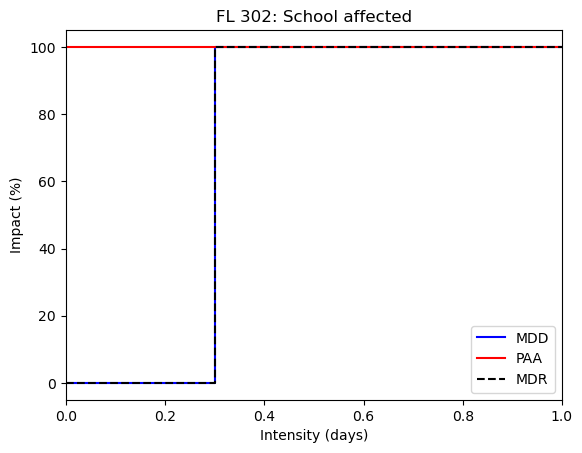

In [32]:
# Modify our Entity to use the default 'affected' impact function
default_impf_affected = entity_count.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_affected)
entity_affected = replace_impact_function(entity_count, default_impf_affected)

# Calculate risk
imp_affected, modelled_affected = risk_calc(entity_affected, haz)
cost = cost_function(modelled_affected, obs_affected_2024)

# Create plots
entity_affected.impact_funcs.plot()
print(f"\nModelled affected schools: {modelled_affected:.0f}")
print(f"Target affected schools: {obs_affected_2024:.0f}")
print(f"Cost: {cost:.2f}% difference")

#### Discussion: first-guess housing affected analysis

The intial plots show us a few things that can guide the calibration:

- We're improving on a first-guess step function where a school is affected if it is flooded for 0.3 days or more
- This underestimates the reported impacts, which we expected


### Affected housing: parameter search

The next blocks of code define a simple parameter search to choose a step function.

In [33]:
import logging

# This will be a simple grid search, where we loop through all combinations of parameters in a defined parameter space, run the risk calculation for each combination, and calculate the cost function for each combination. 
# We then identify the parameter combination that gives the lowest cost function value.

# First: define the parameter space that we'll be exploring
# For a step function this is a single parameter:
parameter_space = {
    "step": np.arange(0.25, 10.25, 0.5)    # Flood duration is an integer value so we test integer steps
}

# Define a method to create a step impact function
def step_function(step, fun_id=None, name=None):
    return ImpactFunc.from_step_impf(
        intensity=(0, step, 90),   # The intensity values at which the impact function changes.
        mdd=(0, 1),                # The mean damage degree values below and above the step.
        paa=(1, 1),                # The percentage of assets affected below and above the step.
        haz_type='FL',
        impf_id=fun_id,
        intensity_unit="days",
        name=name
    )


# Then, we loop through the parameter space, run the risk calculation, and calculate the cost function for each value.
# We store the results in a list.
def search_for_step_impf(
        entity: Entity,
        impf_id: int,
        step_values: np.ndarray,
        obs_target: float):
    # Suppress logging from a couple of climada modules which can be very verbose when running many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for step in step_values:
        print(f"Running risk calculation for step={step:.2f} ...")
            
        # Create a new impact function based on the original
        impf_old = entity.impact_funcs.get_func(haz_type='FL', fun_id=impf_id)
        impf_new = step_function(step, fun_id=impf_id, name=impf_old.name)

        # Update the entity object with the new impact function
        entity_new = replace_impact_function(entity, impf_new)

        # Rerun the risk calculation and calculate the cost function as before
        _, modelled_affected = risk_calc(entity_new, haz)
        cost = cost_function(modelled_affected, obs_target)

        # Store the results
        results.append({
            "step": step,
            "cost": cost
        })

    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)
    return pd.DataFrame(results)


results_affected_df = search_for_step_impf(
    entity=entity_affected,
    impf_id=impf_id_affected,
    step_values=parameter_space["step"],
    obs_target=obs_affected_2024
)
display(results_affected_df)

Running risk calculation for step=0.25 ...
Running risk calculation for step=0.75 ...
Running risk calculation for step=1.25 ...
Running risk calculation for step=1.75 ...
Running risk calculation for step=2.25 ...
Running risk calculation for step=2.75 ...
Running risk calculation for step=3.25 ...
Running risk calculation for step=3.75 ...
Running risk calculation for step=4.25 ...
Running risk calculation for step=4.75 ...
Running risk calculation for step=5.25 ...
Running risk calculation for step=5.75 ...
Running risk calculation for step=6.25 ...
Running risk calculation for step=6.75 ...
Running risk calculation for step=7.25 ...
Running risk calculation for step=7.75 ...
Running risk calculation for step=8.25 ...
Running risk calculation for step=8.75 ...
Running risk calculation for step=9.25 ...
Running risk calculation for step=9.75 ...


,step,cost
0,0.25,53.125
1,0.75,53.125
2,1.25,54.375
3,1.75,54.375
4,2.25,54.375
5,2.75,54.375
6,3.25,54.375
7,3.75,54.375
8,4.25,54.375
9,4.75,54.375


From this search we can identify the 'best' impact function and visualize the results:

In [34]:
# Get the index of the minimum value of 'cost'
def get_best_result(results_df):
    ix_best = results_df['cost'].idxmin()
    best_parameters = results_df.loc[ix_best, :]
    return dict(best_parameters)

best_affected_parameters = get_best_result(results_affected_df)
print(f"Best step value: {best_affected_parameters['step']:.2f} with cost: {best_affected_parameters['cost']:.2f}")

Best step value: 0.25 with cost: 53.12


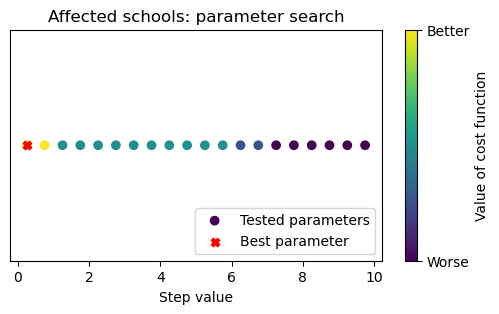

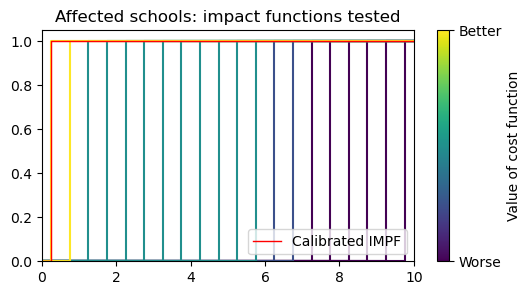

In [35]:
from matplotlib.colors import to_hex

# -------------------------------------------
# Methods to visualize the parameter search
# -------------------------------------------

# Helper function for assigning colours to scatter points
def assign_colour_to_costs(results_df):
    # Map the cost to a color according to viridis, where the best score (lowest) is yellow and the worst score (highest) is purple
    # we can do this by normalising the cost to be between 0 and 1, where 0 corresponds to the best 1 corresponds to the worst score
    # In addition, we take the logarithm of the cost to make the differences between smaller costs more visible
    costs = np.log10(results_df['cost'] + 1e-6)  # Add a small value to avoid taking log of zero
    max_score = costs.max()
    min_score = costs.min()
    norm_scores = 1 - (costs - min_score) / (max_score - min_score)
    results_df['colour'] = [to_hex(plt.cm.viridis(score)) for score in norm_scores]
    results_df = results_df.sort_values('cost', ascending=False)  # Also sort the dataframe by cost so that the best scores are plotted on top
    return results_df

# Plot the parameter search space, with points coloured according to the cost function value (yellow = good, purple = bad)
def plot_step_search_space(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_step = get_best_result(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df['step'], np.zeros_like(results_df['step']), color=results_df['colour'], label='Tested parameters')
    axis.scatter(best_step['step'], 0, color='red', label='Best parameter', marker='X')
    axis.legend(loc="lower right")

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])
    
    axis.set_xlabel("Step value")
    axis.set_yticks([])
    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

# Plot all the impact functions tested in the parameter search, coloured according to the cost function value
def plot_step_search_impfs(results_df, title):
    results_df = assign_colour_to_costs(results_df)
    best_step = get_best_result(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = step_function(params['step'])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = step_function(best_step['step'])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Calibrated IMPF')
    axis.legend(loc="lower right")

    axis.set_xlim((0, 10))
    axis.set_ylim((0, 1.05))

    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_title(title)
    plt.show()
    plt.close(axis.figure)

plot_step_search_space(results_affected_df, "Affected schools: parameter search")
plot_step_search_impfs(results_affected_df, "Affected schools: impact functions tested")

In [36]:
# Recreate the impact calculation with the best parameter values:
impf_best_affected = step_function(best_affected_parameters['step'], fun_id=default_impf_affected.id, name=default_impf_affected.name)

# Update the entity object with the new impact function
entity_affected = replace_impact_function(entity_count, impf_best_affected)

# Rerun the risk calculation and calculate the cost function as before
imp, modelled_affected = risk_calc(entity_affected, haz)
cost = cost_function(modelled_affected, obs_affected_2024)

print(f"\nModelled affected schools: {modelled_affected:.0f}")
print(f"Target affected schools: {obs_affected_2024:.0f}")
print(f"Cost: {cost:.2f}% difference")

2026-06-11 18:17:03,946 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-11 18:17:03,950 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.

Modelled affected schools: 75
Target affected schools: 160
Cost: 53.12% difference


### Discussion: optimized affected schools

The selected impact function for affected schools tells us a few things:

- No matter what threshold we choose, we can't model more than 75 affected schools. This is the number of schools that experience any amount of flooding.
- We are therefore underestimating school impacts by about 50%
- This is an issue with the input data: the Exposures data and the loss observations must disagree in some way. Since both contain information on 'affected schools' this is likely to be either about what a school is, or what counts as 'affected'

Why don't lower flood duration step thresholds push up the impacts? We can see that the threshold of 0.25 gives the same result as 0.75. This is because the hazard measures flood duration in _integer_ days. That is, the lowest positive flood duration is 1 day. Any threshold below this will give the same result.

So for now we can't improve on this. Future work need to repeat this analysis on a different, complete dataset of schools in Porto Alegre.


### A note on the economic value of schools 

This discrepancy in school dataset will cause issues in the calibration: if we can't model the number of schools affected, it's likely that we'll have errors in the loss calculations. 

We have attempted to mitigate this a little by choosing a high economic value for an average school – we give each one a value of 2.5 mn USD, which is at the upper end of the data that we have seen for rebuilding schools in Rio Grande do Sul. By choosing this high value we are partially compensating for the low number of schools in our affected Exposure dataset, and we think this will improve the loss modelling in the absence of further data.

## Economic loss curve calibration

Now we look at calibrating a loss curve for economic costs. The goal here is to reproduce the reported losses to schools.

In this calibration we want to adjust an existing flood loss curve. There are a lot of ways to approach this: here we will apply scalings along the x- and y-axis to stretch the first-guess function (capping a cap at 100% loss). Other approaches might translate along the x-axis instead of stretching, or might look at ways to change the shape of the function.


### First-guess analysis

Our Entity file has a first-guess impact function for economic losses. This is what we'll be improving on:

2026-06-11 18:17:03,998 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-11 18:17:04,014 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.

Modelled losses: 45,750,000 USD
Target losses: 121,867,740 USD
Cost: 62.46% difference


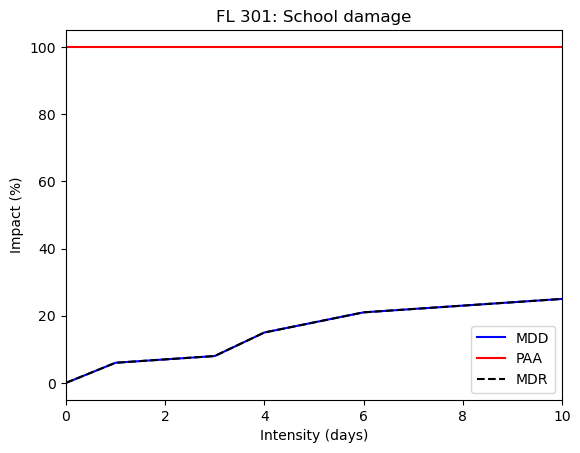

In [37]:
# Calculate uncalibrated losses
imp_losses, modelled_loss = risk_calc(entity_usd, haz)  # No need to change the impact function since the Entity file is set up to use the loss curve by deafult
cost = cost_function(modelled_loss, obs_loss_2024)
default_impf_loss = entity_usd.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_loss)

default_impf_loss.plot()
print(f"\nModelled losses: {modelled_loss:,.0f} USD")
print(f"Target losses: {obs_loss_2024:,.0f} USD")
print(f"Cost: {cost:.2f}% difference")

#### Discussion: first-guess losses

The intial analysis shows us that the impact function is low: we want to approximately double the losses.

Given that there is a single loss observation, there are a lot of ways this can be accomplished. Therefore we will need to think about what is realistic.

### Economic loss: parameter search

The next blocks of code define the parameter search:

In [38]:
import logging

# This will be a simple grid search, where we loop through all combinations of parameters in a defined parameter space, run the risk calculation for each combination, and calculate the cost function for each combination. 
# We then identify the parameter combination that gives the lowest cost function value.

# First: define the parameter space that we'll be exploring
# We now use two parameters:

parameter_space = {
    # The function's maximum intensity, above which there is no change in loss. Determines scaling along the x-axis
    "max_intensity": np.arange(0.25, 80.1, 0.75),
    # The function's maximum % damage. Determines scaling along the y-axis so that the function
    "max_damage": np.arange(0.5, 1.21, 0.015),
}


# Define a method that scales an impact function
def scale_impf(impf, max_damage, max_intensity):
    impf_new = copy.deepcopy(impf)   # Make a copy of the impact function to adjust
    x_scale = max_intensity / impf.intensity.max()
    impf_new.intensity = impf_new.intensity * x_scale
    y_scale = max_damage / impf.mdd.max()
    impf_new.mdd = impf_new.mdd * y_scale
    impf_new.mdd = np.clip(impf_new.mdd, 0, 1)   # Ensure that the damage fraction stays between 0 and 1
    return impf_new


def search_for_loss_impf(
        entity: Entity,
        impf_id: int,
        param_space: dict,
        obs_target: pd.Series
    ):
    # Suppress logging from a couple of climada modules which can be very verbose when running many calculations in a loop
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.WARNING)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.WARNING)

    results = []
    for max_damage in param_space["max_damage"]:
        print(f"Running risk calculations for max_damage={max_damage:.3f} with {len(param_space['max_intensity'])} max_intensity values...")
        for max_intensity in param_space["max_intensity"]:
            # Create a new impact function based on the original
            impf_loss = entity.impact_funcs.get_func(haz_type='FL', fun_id=impf_id)
            impf_new = scale_impf(impf_loss, max_damage, max_intensity)

            # Update the entity object with the new impact function
            entity_new = replace_impact_function(entity, impf_new)

            # Rerun the risk calculation and calculate the cost function as before
            _, modelled_stats = risk_calc(entity_new, haz)
            cost = cost_function(modelled_stats, obs_target)

            # Store the results
            results.append({
                "max_damage": max_damage,
                "max_intensity": max_intensity,
                "cost": cost
            })
    
    logging.getLogger("climada.engine.impact_calc").setLevel(logging.INFO)
    logging.getLogger("climada.entity.exposures.base").setLevel(logging.INFO)

    return pd.DataFrame(results)

results_loss_df = search_for_loss_impf(
    entity=entity_usd,
    impf_id=impf_id_loss,
    param_space=parameter_space,
    obs_target=obs_loss_2024
)
display(results_loss_df.sort_values('cost').head(10))


Running risk calculations for max_damage=0.500 with 107 max_intensity values...
Running risk calculations for max_damage=0.515 with 107 max_intensity values...
Running risk calculations for max_damage=0.530 with 107 max_intensity values...
Running risk calculations for max_damage=0.545 with 107 max_intensity values...
Running risk calculations for max_damage=0.560 with 107 max_intensity values...
Running risk calculations for max_damage=0.575 with 107 max_intensity values...
Running risk calculations for max_damage=0.590 with 107 max_intensity values...
Running risk calculations for max_damage=0.605 with 107 max_intensity values...
Running risk calculations for max_damage=0.620 with 107 max_intensity values...
Running risk calculations for max_damage=0.635 with 107 max_intensity values...
Running risk calculations for max_damage=0.650 with 107 max_intensity values...
Running risk calculations for max_damage=0.665 with 107 max_intensity values...
Running risk calculations for max_damage

,max_damage,max_intensity,cost
1188,0.665,8.50,0.002699
2086,0.785,40.00,0.002880
2853,0.890,53.50,0.003994
1071,0.650,1.00,0.005957
1070,0.650,0.25,0.005957
2416,0.830,46.75,0.031145
3400,0.965,62.50,0.044491
1533,0.710,26.50,0.045406
1307,0.680,17.50,0.046165
3838,1.025,70.00,0.053827


Best parameter combination:
max_intensity: 8.50
max_damage: 0.67
Cost: 0.00


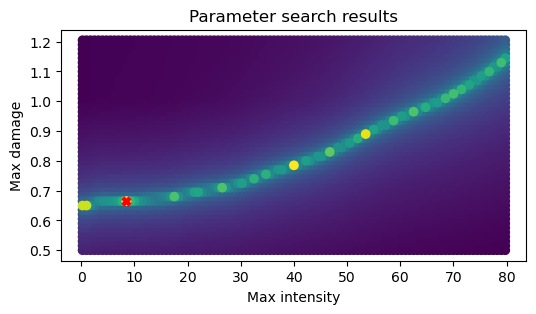

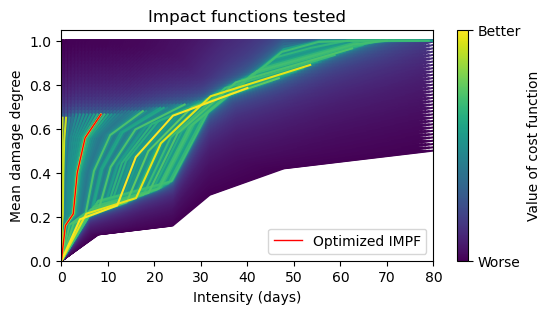

In [39]:
# ------------------------------------
# Visualize the parameter search results, now in two dimensions
# ------------------------------------

def plot_loss_search_space(results_df, best_params):
    # Map the cost to a color according to viridis, where the best score (lowest) is yellow and the worst score (highest) is purple
    # we can do this by normalising the cost to be between 0 and 1, where 0 corresponds to the best 1 corresponds to the worst score
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    axis.scatter(results_df['max_intensity'], results_df['max_damage'], color=results_df['colour'])
    axis.scatter(best_params['max_intensity'], best_params['max_damage'], color='red', label='Best parameter combination', marker='X')
    axis.set_xlabel("Max intensity")
    axis.set_ylabel("Max damage")
    axis.set_title("Parameter search results")

def plot_loss_search_impfs(results_df, best_params, impf_orig):
    results_df = assign_colour_to_costs(results_df)
    fig, axis = plt.subplots(figsize=(6, 3))
    for _, params in results_df.iterrows():
        impf_new = scale_impf(impf_orig, params['max_damage'], params['max_intensity'])
        axis.plot(impf_new.intensity, impf_new.mdd, color=params['colour'])

    best_impf = scale_impf(impf_orig, best_params['max_damage'], best_params['max_intensity'])
    axis.plot(best_impf.intensity, best_impf.mdd, color='red', linewidth=1, label='Optimized IMPF')

    axis.legend(loc="lower right")
    
    axis.cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axis)
    axis.cbar.set_label('Value of cost function')
    axis.cbar.set_ticks([0, 1])
    axis.cbar.set_ticklabels(['Worse', 'Better'])

    axis.set_xlim((0, 80))
    axis.set_ylim((0, 1.05))
    axis.set_xlabel("Intensity (days)")
    axis.set_ylabel("Mean damage degree")
    axis.set_title("Impact functions tested")

    plt.show()
    plt.close(axis.figure)

best_loss_parameters = get_best_result(results_loss_df)
print(f"Best parameter combination:")
print(f"max_intensity: {best_loss_parameters['max_intensity']:.2f}")
print(f"max_damage: {best_loss_parameters['max_damage']:.2f}")
print(f"Cost: {best_loss_parameters['cost']:.2f}")

impf_orig = entity_usd.impact_funcs.get_func(haz_type='FL', fun_id=impf_id_loss)
plot_loss_search_space(results_loss_df, best_loss_parameters)
plot_loss_search_impfs(results_loss_df, best_loss_parameters, impf_orig)

2026-06-11 18:19:09,563 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-11 18:19:09,575 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.

Modelled losses: 121,871,029 USD
Target losses: 121,867,740 USD
Cost: 0.00% difference


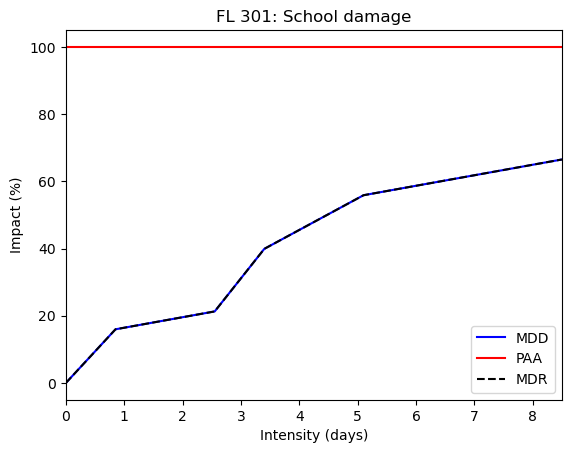

In [40]:
# Recreate the impact calculation with the best parameter values:
impf_best_loss = scale_impf(impf_orig, best_loss_parameters['max_damage'], best_loss_parameters['max_intensity'])

# Update the entity object with the new impact function
entity_loss = replace_impact_function(entity_usd, impf_best_loss)

# Rerun the risk calculation and calculate the cost function as before
imp_optimized, modelled_loss = risk_calc(entity_loss, haz)
cost = cost_function(modelled_loss, obs_loss_2024)

impf_best_loss.plot()
print(f"\nModelled losses: {modelled_loss:,.0f} USD")
print(f"Target losses: {obs_loss_2024:,.0f} USD")
print(f"Cost: {cost:.2f}% difference")


### Discussion: economic loss

The algorithm identified a whole family of potential impact functions. In the plot of the parameter space, we see a curve of near perfect fits crossing the space, shaded in yellow.

This is unsurprising: given that we are calibrating to a _single_ target observation, we would expect that, for every value of `max_intensity` there is a value of `max_damage` that can reproduce the observations: you only need one degree of freedom to match one observation.

This leaves us with a challenge: without further observations we can't decide which point in the parameter space is most suitable. The function chosen by the algorithm is almost at random: it's whichever point in the parameter space happens to be closest to the 'true' curve. (Change the `parameter_space` bounds to see this in action: you may get an optimal curve that maxes out at 2 days, or at 80 days.)

We need more information to make a good choice. Without that we have to use expert judgement.

If we choose a curve to the left of the parameter space, we get a function which is steep at first and then maxes out at a low value, meaning that anywhere flooded for a few days experiences loss, but losses are capped at 50-60%%.

If we choose a curve to the right of the parameter space, we get a function where losses increase slowly with flood duration, and reach their maximum after 60 days or more.


### Choice of calibrated function

We can therefore specify some subjective choices, based on our experience of flood losses.

For example, we could decide that maximum impact should be above 70% (`max_damage > 0.7`), since we know several schools were completely rebuilt. Looking at the earlier charts this means that the flood impacts will increase with up to 25 or more days of flood duration: let's set it to be max out at under 30 (`max_intensity < 30`).

You can adjust these as you like and see how it affects the impact function.

### Conclusion

There is more work to be done before this impact function can be used with confidence.

The calibration here is a particular challenge: it is hard to calibrate to a single observation, and it is even harder when your Exposure data doesn't align well with the observations you're trying to reproduce. This final impact function was chosen from a large family of equally plausible functions, given what we know. Further research would improve the analysis greatly: either by extending the school exposure data, aligning definitions of 'affected' between the input data sources, or finding further observations, either from other events, or splitting the 2024 data into Bairros to compare individual locations.

Best parameters among filtered results:
Max damage: 0.71
Max intensity: 26.50
2026-06-11 18:19:11,250 - climada.entity.exposures.base - INFO - Exposures matching centroids already found for FL
2026-06-11 18:19:11,261 - climada.engine.impact_calc - INFO - Calculating impact for 610 assets (>0) and 1 events.

Modelled losses: 121,923,075 USD
Target losses: 121,867,740 USD
Cost: 0.05% difference


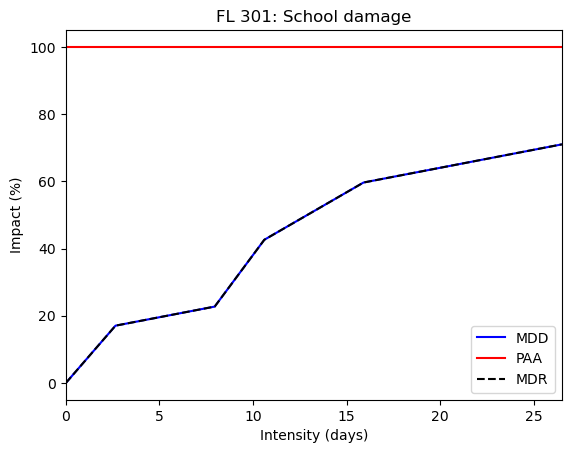

In [41]:
filtered_results = results_loss_df[
    (results_loss_df['max_damage'] > 0.7) &
    (results_loss_df['max_intensity'] < 30)
]

best_filtered_params = get_best_result(filtered_results)
print(f"Best parameters among filtered results:")
print(f"Max damage: {best_filtered_params['max_damage']:.2f}")
print(f"Max intensity: {best_filtered_params['max_intensity']:.2f}")

impf_chosen = scale_impf(
    impf=impf_orig,
    max_damage=best_filtered_params['max_damage'],
    max_intensity=best_filtered_params['max_intensity']
)
impf_chosen.plot()

# Update the entity object with the new impact function
entity_usd_chosen = replace_impact_function(entity_usd, impf_chosen)

# Rerun the risk calculation and calculate the cost function as before
imp_chosen, modelled_stats = risk_calc(entity_usd_chosen, haz)
cost = cost_function(modelled_stats, obs_loss_2024)
print(f"\nModelled losses: {modelled_stats:,.0f} USD")
print(f"Target losses: {obs_loss_2024:,.0f} USD")
print(f"Cost: {cost:.2f}% difference")

Text(0.5, 1.0, 'Comparison of impact functions')

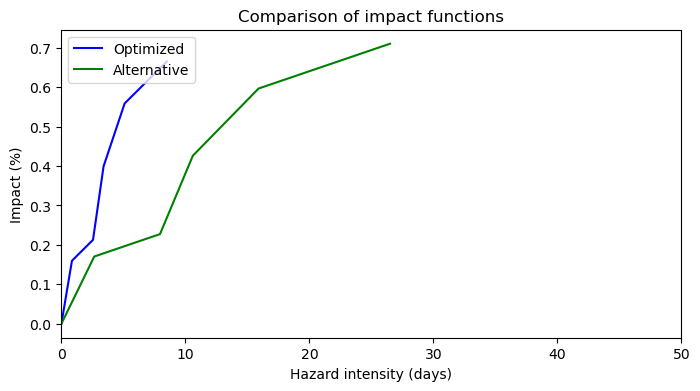

In [42]:
# Plot the two impact functions
fig, axis = plt.subplots(figsize=(8, 4))
axis.plot(impf_best_loss.intensity, impf_best_loss.mdd, color='blue', label='Optimized')
axis.plot(impf_chosen.intensity, impf_chosen.mdd, color='green', label='Alternative')
axis.set_xlabel("Hazard intensity (days)")
axis.set_ylabel("Impact (%)")
axis.set_xlim((0, 50))
axis.legend(loc="upper left")
axis.set_title("Comparison of impact functions")

## Write calibrated Entity file

This is a manual process. The code below copies the Entity file to the data/entity_files_calibrated folder and prints out the chosen impact functions.

You can then update the impact functions in the Excel file by copying the table over.

In [43]:
import shutil

entity_final = copy.deepcopy(entity_usd)

# Swap in the new impact functions for loss, affected, and destroyed
new_impfset = ImpactFuncSet([impf_chosen, impf_best_affected])
old_impf_ids = [impf.id for impf in entity_final.impact_funcs.get_func(haz_type='FL')]
new_impf_ids = [impf.id for impf in new_impfset.get_func(haz_type='FL')]
assert np.array_equal(old_impf_ids, new_impf_ids), "The new impact function IDs do not match the old ones"
entity_final.impact_funcs = new_impfset

# Copy over original file and update with calibrated impact functions
shutil.copy(entity_filepath, calibrated_entity_filepath)

# Open the impact_functions sheet in the Excel file and overwrite with the new impact functions
impf_export_list = []
for impf in [impf_chosen, impf_best_affected]:
    impf_df = pd.DataFrame({
        "impact_fun_id": impf.id,
        "intensity_m": impf.intensity,
        "mdd": impf.mdd,
        "paa": impf.paa,
        "peril_id": "FL",
        "name": impf.name,
        "intensity_unit": "meter"
    })
    impf_export_list.append(impf_df)

impf_export_df = pd.concat(impf_export_list, ignore_index=True)

print(f"Final impact functions. Copy into Excel file to overwrite the original impact functions:")
display(impf_export_df.style.format({
    "impact_fun_id": "{:d}",
    "intensity_m": "{:.3f}",
    "mdd": "{:.3f}",
    "paa": "{:.3f}"
}))


Final impact functions. Copy into Excel file to overwrite the original impact functions:


,impact_fun_id,intensity_m,mdd,paa,peril_id,name,intensity_unit
0,301,0.000,0.000,1.000,FL,School damage,meter
1,301,2.650,0.170,1.000,FL,School damage,meter
2,301,5.300,0.199,1.000,FL,School damage,meter
3,301,7.950,0.227,1.000,FL,School damage,meter
4,301,10.600,0.426,1.000,FL,School damage,meter
5,301,13.250,0.511,1.000,FL,School damage,meter
6,301,15.900,0.596,1.000,FL,School damage,meter
7,301,18.550,0.625,1.000,FL,School damage,meter
8,301,21.200,0.653,1.000,FL,School damage,meter
9,301,23.850,0.682,1.000,FL,School damage,meter
